In [6]:
import pandas as pd
data = pd.read_csv("C:/Users/RK/Downloads/capstone_geak/data/feature_engineered_data.csv")

In [7]:
# Convert regression → classification
threshold = data['log_qty'].median()

data['demand_class'] = (data['log_qty'] > threshold).astype(int)

In [8]:
X = data.drop(
    ['log_qty', 'demand_class', 'qty', 'total_price', 'demand_per_price'],
    axis=1,
    errors='ignore'  
)

y = data['demand_class']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

c:\Users\RK\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [13]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.823529
1,Random Forest,0.899160
2,XGBoost,0.907563


Hyperparameter Tuning

In [14]:
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(eval_metric='logloss')

random_search = RandomizedSearchCV(
    xgb,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_iter=10,
    random_state=42
)

random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

In [15]:
print("Best Params:", random_search.best_params_)
print("Best CV Score:", random_search.best_score_)

Best Params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1}
Best CV Score: 0.9092497200447929


Model Evaluation

In [16]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

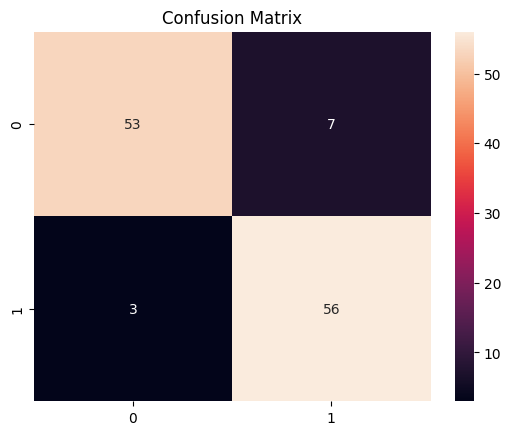

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.88      0.91        60
           1       0.89      0.95      0.92        59

    accuracy                           0.92       119
   macro avg       0.92      0.92      0.92       119
weighted avg       0.92      0.92      0.92       119



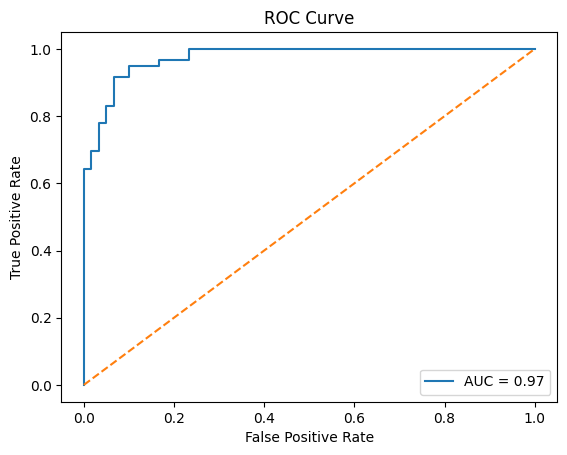

In [19]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [27]:
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier


# Load Data
def load_data(path):
    return pd.read_csv(path)


# Preprocessing
def preprocess(data):
    # Create classification target
    data['demand_class'] = (data['log_qty'] > data['log_qty'].median()).astype(int)

    # Drop unnecessary / leakage columns
    drop_cols = ['log_qty', 'demand_class', 'qty', 'total_price', 'demand_per_price']
    X = data.drop(columns=[col for col in drop_cols if col in data.columns])

    y = data['demand_class']

    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


# Train Model
def train_model(X_train, y_train):
    model = XGBClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        subsample=0.8,
        eval_metric='logloss'
    )
    model.fit(X_train, y_train)
    return model


# Evaluate Model
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"Model Accuracy: {acc:.4f}")


# Save Model
def save_model(model, path):
    joblib.dump(model, path)


# Run Pipeline
if __name__ == "__main__":
    data = load_data("C:/Users/RK/Downloads/capstone_geak/data/feature_engineered_data.csv")
    X_train, X_test, y_train, y_test = preprocess(data)

    model = train_model(X_train, y_train)

    evaluate_model(model, X_test, y_test)

save_model(model, "C:/Users/RK/Downloads/capstone_geak/model/trained_model.pkl")


Model Accuracy: 0.9160


Model Explainability

In [28]:
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10))

                                  Feature  Importance
13                                      s    0.127023
32    product_category_name_health_beauty    0.072227
21                                 comp_3    0.066335
7                               customers    0.065577
35                     price_per_customer    0.063739
1                              unit_price    0.047609
15                                 comp_1    0.046555
39                           price_change    0.041113
30  product_category_name_furniture_decor    0.034099
9                                 weekend    0.032989


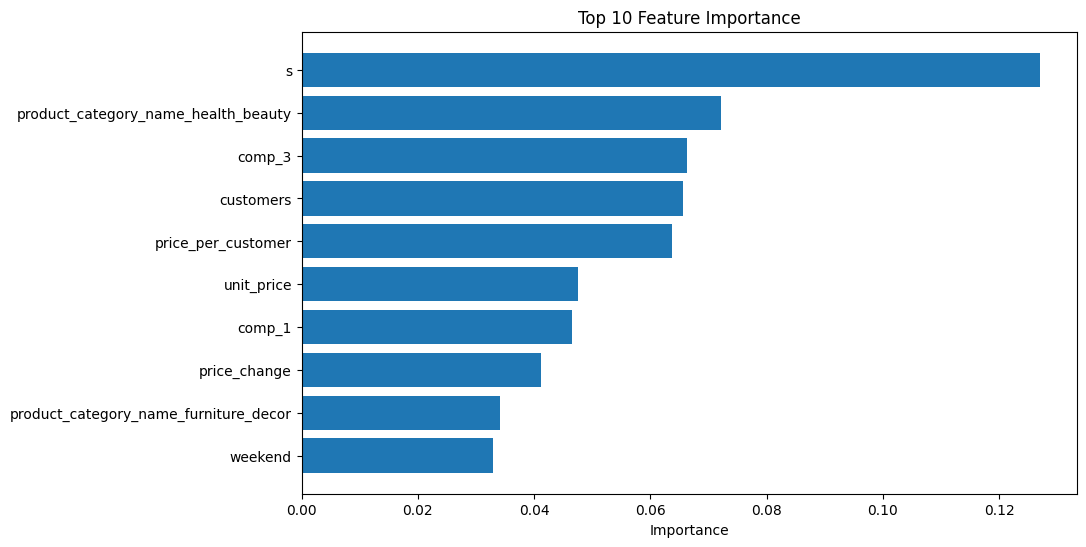

In [29]:
plt.figure(figsize=(10,6))
plt.barh(feature_importance_df['Feature'][:10], feature_importance_df['Importance'][:10])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.show()

In [30]:
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

In [31]:
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [33]:
import numpy as np# Convert all to float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

# Handle infinite values
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# Fill missing values
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

In [35]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [38]:
import shap
explainer = shap.Explainer(model.predict, X_train.iloc[:100])
shap_values = explainer(X_test.iloc[:50])

c:\Users\RK\AppData\Local\Python\pythoncore-3.10-64\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
PermutationExplainer explainer: 51it [00:21,  2.37it/s]                        


C:\Users\RK\AppData\Local\Temp\ipykernel_1716\3610483394.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test.iloc[:50])


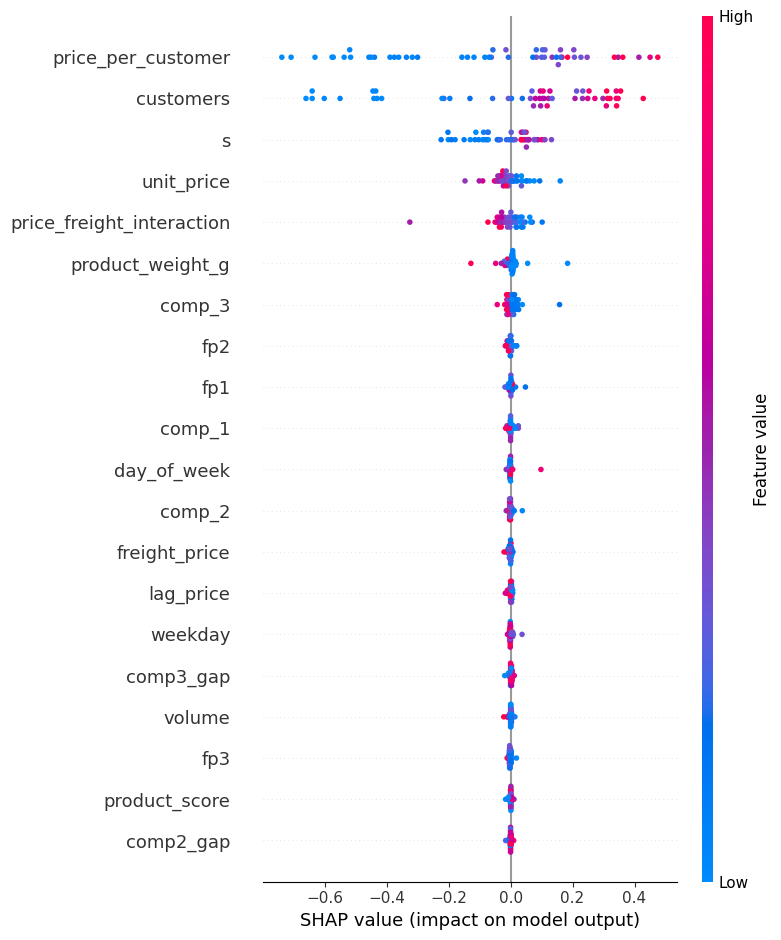

In [39]:
shap.summary_plot(shap_values, X_test.iloc[:50])

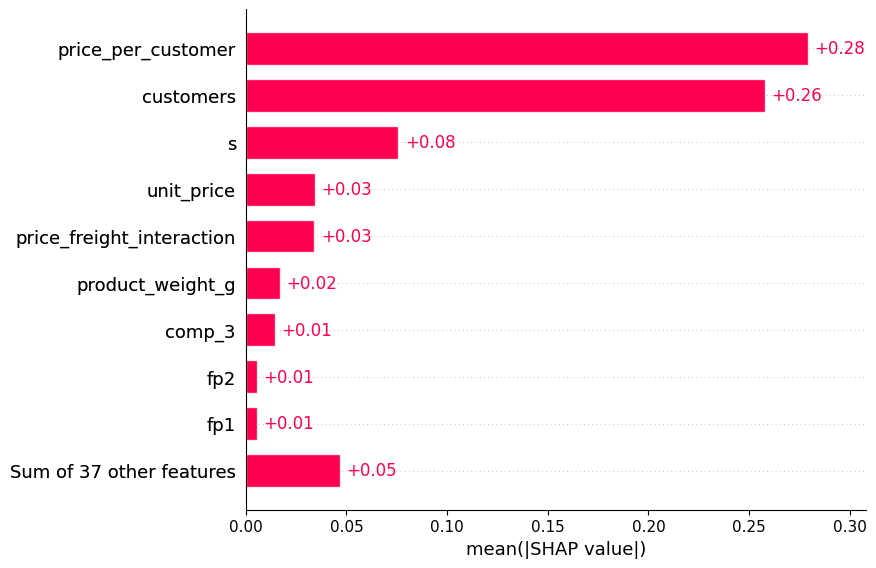

In [40]:
shap.plots.bar(shap_values)

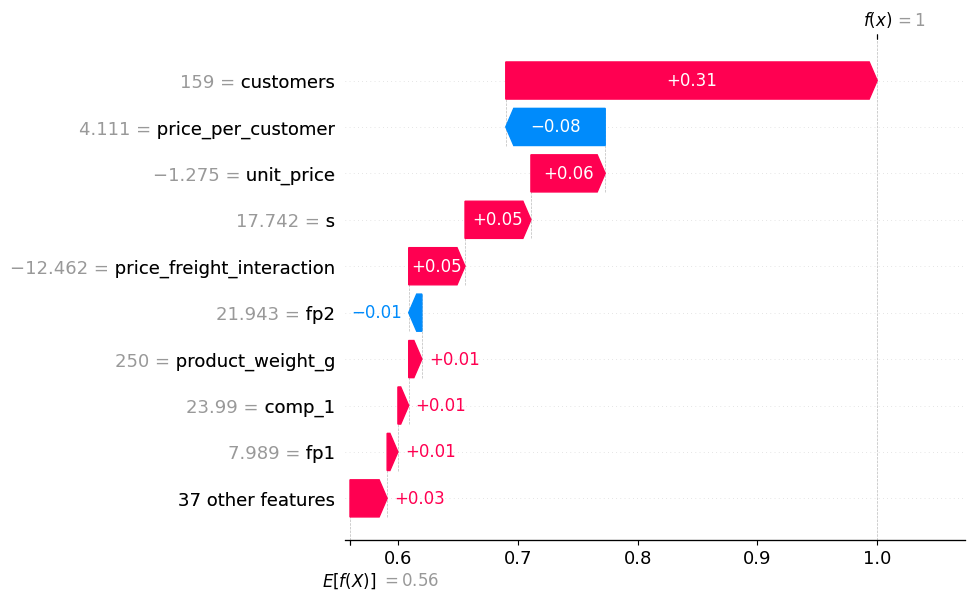

In [41]:
shap.plots.waterfall(shap_values[0])

In [42]:
import joblib

# Save column names
joblib.dump(X_train.columns.tolist(), "../model/columns.pkl")

['../model/columns.pkl']

In [43]:
model = joblib.load("../model/trained_model.pkl")
columns = joblib.load("../model/columns.pkl")   # ✅ load columns